In [ ]:
import torch
import numpy as np
import matplotlib as plt
from src.datasets.mos2_sr import MOS2SRDataset

dataset = MOS2SRDataset()

# **1. GPR**
---

In [ ]:
from src.models.prev_methods.gpr import gpr_sr

item = dataset[0]
y = item["y"]
y_sparse = item["y_sparse"]

y_hat = gpr_sr(y_sparse)

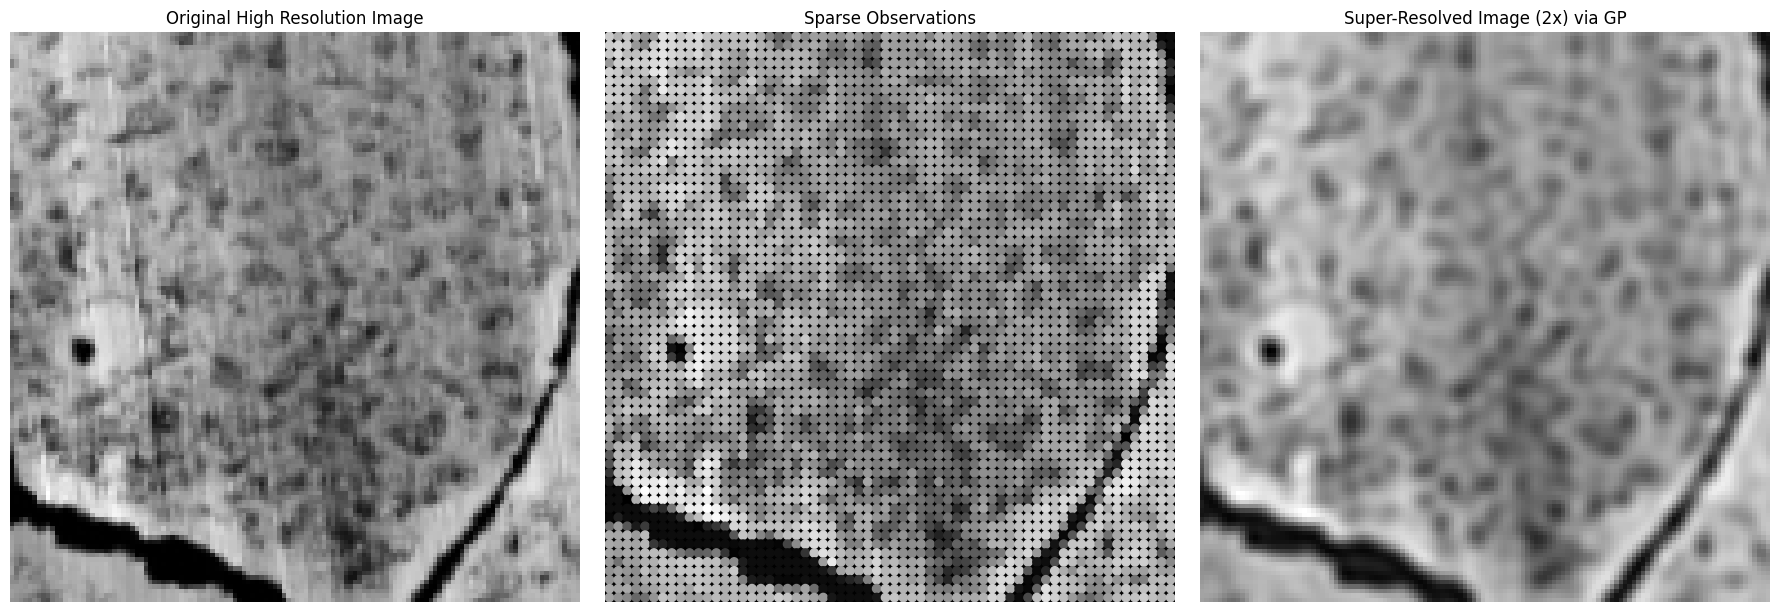

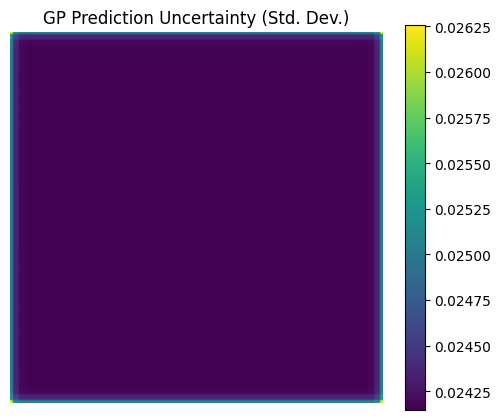

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# --------------------------
# Load data from the dataset
# --------------------------
# Here we assume that the dataset item provides two images:
#   y         : The original high resolution image (H, W)
#   y_sparse  : A sparse observation (H, W) with missing pixels as np.nan
item = dataset[0]
y = item["y"].cpu().numpy()                # Ground truth image (H, W)
y_sparse = item["y_sparse"].cpu().numpy()  # Sparse observation (H, W)

# --------------------------
# Prepare the training data
# --------------------------
H, W = y_sparse.shape

# Find the indices (pixel coordinates) where the sparse image has valid (non-NaN) data.
# Each training sample is a coordinate (row, col) with its corresponding intensity.
train_indices = np.argwhere(~np.isnan(y_sparse))  # shape: (n_samples, 2)
y_train = y_sparse[~np.isnan(y_sparse)]

# Normalize the coordinates to [0, 1]. Normalization helps the GP kernel work well.
# We divide by (H-1) and (W-1) so that the top-left is (0,0) and bottom-right is (1,1)
X_train = train_indices.astype(np.float64)
X_train[:, 0] /= (H - 1)
X_train[:, 1] /= (W - 1)

# --------------------------
# Define and fit the GP model
# --------------------------
# The kernel combines a Radial Basis Function (RBF) to capture smooth variations,
# plus a WhiteKernel to account for noise in the observations.
kernel = RBF(length_scale=0.1, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)

# Fit the GP model on the normalized training coordinates and pixel intensities.
gp.fit(X_train, y_train)

# --------------------------
# Create a high resolution grid for prediction (2x upscaling)
# --------------------------
# The new grid will have dimensions (2H, 2W). We create a grid of points evenly spaced in [0,1].
H_hr, W_hr = 2 * H, 2 * W
grid_x = np.linspace(0, 1, H_hr)
grid_y = np.linspace(0, 1, W_hr)
xx, yy = np.meshgrid(grid_x, grid_y, indexing='ij')
X_pred = np.column_stack([xx.ravel(), yy.ravel()])  # shape: (2H*2W, 2)

# Use the GP to predict the pixel intensities on the high resolution grid.
y_pred, y_std = gp.predict(X_pred, return_std=True)
y_pred_img = y_pred.reshape(H_hr, W_hr)
y_std_img = y_std.reshape(H_hr, W_hr)

# --------------------------
# Plot the results
# --------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original high resolution image
axes[0].imshow(y, cmap='gray')
axes[0].set_title('Original High Resolution Image')
axes[0].axis('off')

# 2. Sparse observations
# Here, to emphasize the sparse data, we use imshow for background and overlay the known points.
axes[1].imshow(np.zeros_like(y_sparse), cmap='gray', vmin=0, vmax=1)
sparse_coords = np.argwhere(~np.isnan(y_sparse))
axes[1].scatter(sparse_coords[:, 1], sparse_coords[:, 0], c=y_sparse[~np.isnan(y_sparse)], cmap='gray')
axes[1].set_title('Sparse Observations')
axes[1].axis('off')

# 3. Super-resolved image from GP prediction
axes[2].imshow(y_pred_img, cmap='gray')
axes[2].set_title('Super-Resolved Image (2x) via GP')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Additionally, plot the GP prediction uncertainty (standard deviation)
plt.figure(figsize=(6, 5))
plt.imshow(y_std_img, cmap='viridis')
plt.title('GP Prediction Uncertainty (Std. Dev.)')
plt.colorbar()
plt.axis('off')
plt.show()